# Imports

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import json
from collections import Counter
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Cleaning

In [ ]:
path = "Datasets/Phase1/dataset_phase1.csv"

df = pd.read_csv(path)
df['specification'] = df['version'].str[:2]
# Extract Task (last character)
df['Task'] = df['version'].str[-1]

df.head()

# hidden tests

In [ ]:
df.describe()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3197775083.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3197775083.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


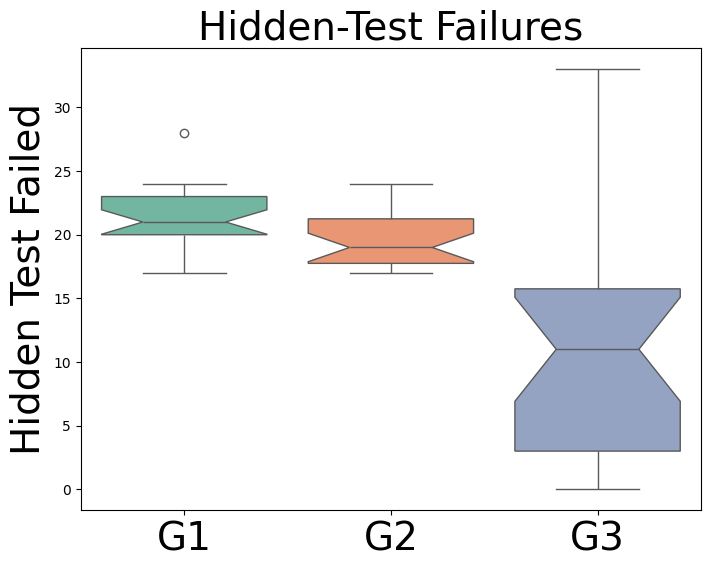

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='num_hidden_test_failed_phase1',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Hidden-Test Failures', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Hidden Test Failed', fontsize=28)
plt.savefig('img/RQ1_hidden_test_failures_by_specifcation.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_hidden_test_failures_by_specifcation.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/606918123.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/606918123.py:11: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


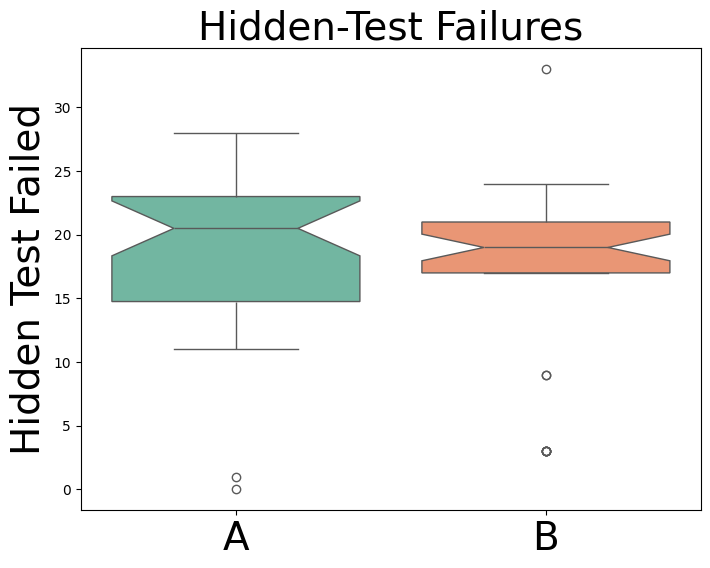

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Task',
    y='num_hidden_test_failed_phase1',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Hidden-Test Failures', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Hidden Test Failed', fontsize=28)
plt.savefig('img/RQ1_hidden_test_failures_by_Task.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_hidden_test_failures_by_Task.pdf', dpi=300, bbox_inches='tight')
plt.show()

### G1: emergent

#### extract G1 data

In [ ]:
G1_df = df[df['specification'] == 'G1'].reset_index(drop=True)
col_drop = [
    "before_g2_ac", "before_g2_constraints", "before_g2_goal", "before_g2_input", "before_g2_output",
    "before_g2_p_1", "before_g2_p_2", "before_g2_p_3", "before_g2_p_4", "before_g2_p_5", "before_g2_p_6",
    "before_g2_p_7", "before_g2_p_8",
    "before_g3_constraints", "before_g3_exception", "before_g3_frs", "before_g3_goal", "before_g3_input",
    "before_g3_invariants", "before_g3_neg_req", "before_g3_output", "before_g3_p_1", "before_g3_p_2",
    "before_g3_p_3", "before_g3_p_4", "before_g3_p_5", "before_g3_p_6", "before_g3_p_7", "before_g3_p_8",
    "before_g3_tie_breaking"
]

G1_df.drop(columns=col_drop, inplace=True)


#### Analysis of G1

In [ ]:
print("full correct: " + str(len(G1_df[G1_df["num_hidden_test_passed_phase1"]>30])))
G1_df["version"].value_counts()

version
G1A    12
G1B    12
Name: count, dtype: int64

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3700473833.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3700473833.py:11: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


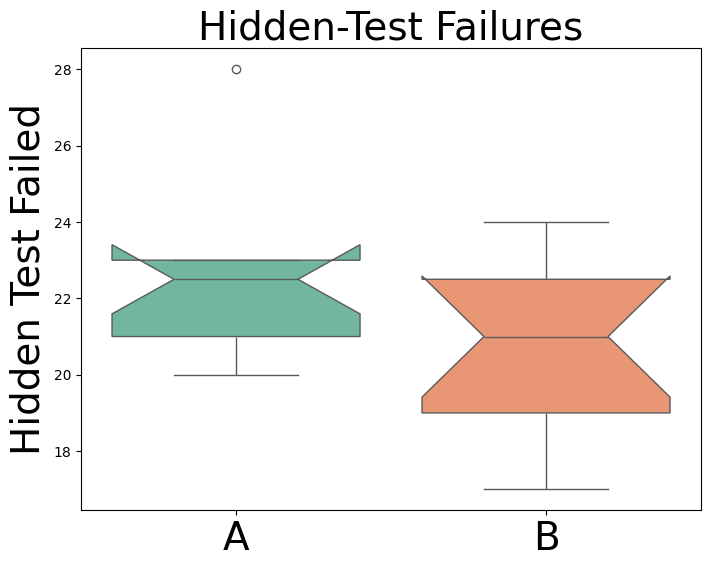

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Task',
    y='num_hidden_test_failed_phase1',
    data=G1_df,
    notch=True,
    palette=palette
)

plt.title('Hidden-Test Failures', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Hidden Test Failed', fontsize=28)
plt.show()

##### Task A

In [ ]:
G1_df_A = G1_df[G1_df["version"] == "G1A"].reset_index(drop=True)
G1_df_A.describe()

#### Task B

In [ ]:
G1_df_B = G1_df[G1_df["version"] == "G1B"].reset_index(drop=True)
G1_df_B.describe()


12

### G2: Structured

#### extract G2

In [ ]:
G2_df = df[df['specification'] == 'G2'].reset_index(drop=True)
col_drop = [
    "before_g1_p_1", "before_g1_p_2", 	"before_g1_p_3",	"before_g1_p_4",	"before_g1_p_5",	"before_g1_p_6",	"before_g1_p_7",	"before_g1_p_8",
    "before_g3_constraints", "before_g3_exception", "before_g3_frs", "before_g3_goal", "before_g3_input",
    "before_g3_invariants", "before_g3_neg_req", "before_g3_output", "before_g3_p_1", "before_g3_p_2",
    "before_g3_p_3", "before_g3_p_4", "before_g3_p_5", "before_g3_p_6", "before_g3_p_7", "before_g3_p_8",
    "before_g3_tie_breaking"
]

G2_df.drop(columns=col_drop, inplace=True)


#### Analysis of G2

In [ ]:
print("full correct: " + str(len(G2_df[G2_df["num_hidden_test_passed_phase1"]>30])))
G2_df["version"].value_counts()

version
G2B    12
G2A    12
Name: count, dtype: int64

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3155469052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3155469052.py:11: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


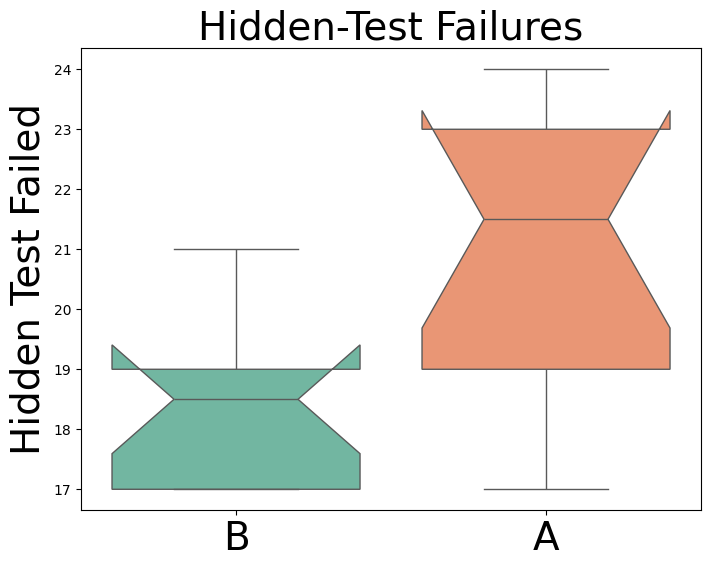

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Task',
    y='num_hidden_test_failed_phase1',
    data=G2_df,
    notch=True,
    palette=palette
)

plt.title('Hidden-Test Failures', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Hidden Test Failed', fontsize=28)
plt.show()

#### Task A

In [ ]:
G2_df_A = G2_df[G2_df["version"] == "G2A"].reset_index(drop=True)
print(len(G2_df_A))
G2_df_A.describe()

#### Task B

In [ ]:
G2_df_B = G2_df[G2_df["version"] == "G2B"].reset_index(drop=True)
print(len(G2_df_B))
G2_df_B.describe()

### G3: Constraint complete

In [ ]:
G3_df = df[df['specification'] == 'G3'].reset_index(drop=True)
col_drop = [
    "before_g2_ac", "before_g2_constraints", "before_g2_goal", "before_g2_input", "before_g2_output",
    "before_g2_p_1", "before_g2_p_2", "before_g2_p_3", "before_g2_p_4", "before_g2_p_5", "before_g2_p_6",
    "before_g2_p_7", "before_g2_p_8", 
    "before_g1_p_1", "before_g1_p_2", 	"before_g1_p_3",	"before_g1_p_4",	"before_g1_p_5",	"before_g1_p_6",	"before_g1_p_7",	"before_g1_p_8"
]

G3_df.drop(columns=col_drop, inplace=True)


#### Analysis of G3

In [34]:
G3_df["version"].value_counts()

version
G3A    12
G3B    12
Name: count, dtype: int64

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/636827717.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/636827717.py:11: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


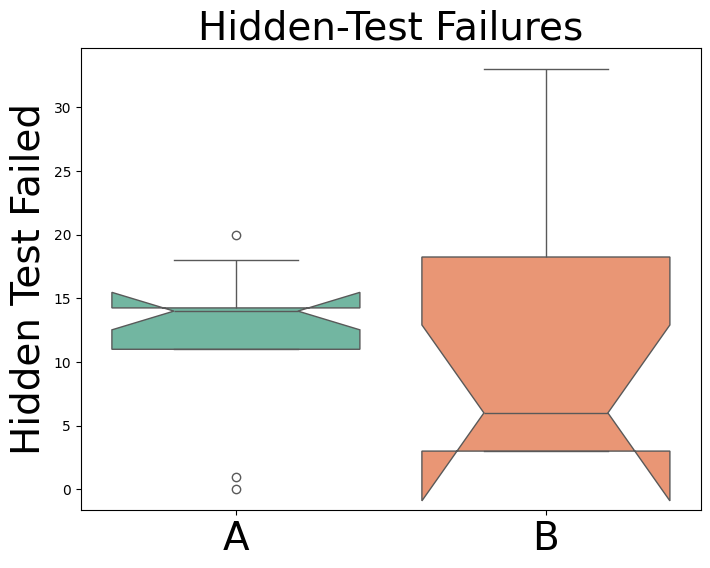

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Task',
    y='num_hidden_test_failed_phase1',
    data=G3_df,
    notch=True,
    palette=palette
)

plt.title('Hidden-Test Failures', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Hidden Test Failed', fontsize=28)
plt.show()

##### Full correctness

In [ ]:
total_tests = {
    "G3B": 33,
    "G3A": 33
}

G3_df["passed_all"] = G3_df.apply(
    lambda row: row["num_hidden_test_passed_phase1"] == total_tests.get(row["version"], 0),
    axis=1
)
print(G3_df[G3_df["passed_all"] == True])
overall_pass_rate = G3_df["passed_all"].mean()
print("Overall pass rate:", overall_pass_rate)
pass_rate_by_version = G3_df.groupby("version")["passed_all"].mean()
print(pass_rate_by_version)

#### Task A

In [ ]:
G3_df_A = G3_df[G3_df["version"] == "G3A"].reset_index(drop=True)
print(len(G3_df_A))
G3_df_A.describe()

#### Task B

In [ ]:
G3_df_B = G3_df[G3_df["version"] == "G3B"].reset_index(drop=True)
print(len(G3_df_B))
G3_df_B.describe()

### create hiddentests.csv


In [ ]:
cols_to_keep = ["id","version","num_hidden_test_passed_phase1","failed_tests_phase1","passed_tests_phase1","num_hidden_test_failed_phase1","specification","Task"]
hidden_df = df[cols_to_keep]
hidden_df.to_csv("Datasets/Phase1/hidden_tests_phase1.csv", index = False)

### Logistic regression

In [ ]:

df = pd.read_csv("Datasets/Phase1/hidden_tests_phase1.csv")
df["correct"] = (df["num_hidden_test_failed_phase1"] == 0).astype(int)
#  Ensure categorical variables
df["specification"] = pd.Categorical(df["specification"], categories=["G1", "G2", "G3"])
df["Task"] = df["Task"].astype("category")


model = smf.logit("correct ~ C(specification) + C(Task)", data=df).fit()

print(model.summary())

params = model.params
pvals = model.pvalues
odds_ratios = np.exp(params)

results = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "p-value": pvals
})

# Only keep specification effects
results = results[results.index.str.contains("specification")]

print("\nSpecification Effects (relative to G1):")
print(results)

# 5. Pretty print results
or_g2 = odds_ratios.get("C(specification)[T.G2]", np.nan)
p_g2 = pvals.get("C(specification)[T.G2]", np.nan)

or_g3 = odds_ratios.get("C(specification)[T.G3]", np.nan)
p_g3 = pvals.get("C(specification)[T.G3]", np.nan)

print("\nReportable Results:")
print(f"G3 vs G1: OR={or_g3:.2f}, p={p_g3:.3g}")
print(f"G2 vs G1: OR={or_g2:.2f}, p={p_g2:.3g}")

         Current function value: 0.047806
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                   72
Model:                          Logit   Df Residuals:                       68
Method:                           MLE   Df Model:                            3
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                  0.3468
Time:                        15:10:38   Log-Likelihood:                -3.4420
converged:                      False   LL-Null:                       -5.2697
Covariance Type:            nonrobust   LLR p-value:                    0.3012
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                -23.8421   4.34e+04     -0.001      1.000   -8.51e+04    8.51e+04
C(specification)[T.G2]    -4.

/Users/elmiraonagh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# failure modes

### statisitcs

#### ANOva for failure

In [ ]:
import pandas as pd
df = pd.read_csv("Datasets/Phase1/hidden_tests_phase1.csv")
g1 = df[df['specification']=='G1']['num_hidden_test_failed_phase1']
g2 = df[df['specification']=='G2']['num_hidden_test_failed_phase1']
g3 = df[df['specification']=='G3']['num_hidden_test_failed_phase1']

In [72]:
from scipy.stats import f_oneway

F, p = f_oneway(g1, g2, g3)

print("F =", F)
print("p =", p)

F = 26.76735999263724
p = 2.4851494907175426e-09


#### Logistic regression for full correctness

In [64]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assuming df is already loaded
# Define a binary correctness: fully correct = passed all hidden tests
df['full_correct'] = np.where(df['num_hidden_test_failed_phase1'] == 0, 1, 0)

# Ensure 'specification' is categorical with G1 as baseline
df['specification'] = pd.Categorical(df['specification'], categories=['G1','G2','G3'])

# Logistic regression: full_correct ~ specification
logit_model = smf.logit('full_correct ~ specification', data=df).fit()

print(logit_model.summary())

# Compute odds ratios and p-values
odds_ratios = pd.DataFrame({
    'OR': np.exp(logit_model.params).round(2),
    'p-value': logit_model.pvalues
})
print("\nOdds Ratios and p-values:")
print(odds_ratios)

# Optional: analyze failure counts (Poisson regression)
poisson_model = smf.poisson('num_hidden_test_failed_phase1 ~ specification', data=df).fit()
print("\nPoisson regression for failure counts:")
print(poisson_model.summary())

         Current function value: 0.057735
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:           full_correct   No. Observations:                   72
Model:                          Logit   Df Residuals:                       69
Method:                           MLE   Df Model:                            2
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.2112
Time:                        11:52:05   Log-Likelihood:                -4.1569
converged:                      False   LL-Null:                       -5.2697
Covariance Type:            nonrobust   LLR p-value:                    0.3286
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -24.8517   5.09e+04     -0.000      1.000   -9.97e+04    9.97e+04
specification[T.G2]    -1.2413   1.07e

/Users/elmiraonagh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### ANOVA for test passed

In [76]:
g1_p = df[df['specification']=='G1']['num_hidden_test_passed_phase1']
g2_p = df[df['specification']=='G2']['num_hidden_test_passed_phase1']
g3_p= df[df['specification']=='G3']['num_hidden_test_passed_phase1']

In [77]:
from scipy.stats import f_oneway

F, p = f_oneway(g1_p, g2_p, g3_p)

print("F =", F)
print("p =", p)

F = 26.76735999263724
p = 2.4851494907175426e-09


In [78]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD for failure count
tukey_failure = pairwise_tukeyhsd(endog=df['num_hidden_test_failed_phase1'], groups=df['specification'], alpha=0.05)
print(tukey_failure)

# Tukey HSD for hidden tests passed
tukey_hidden = pairwise_tukeyhsd(endog=df['num_hidden_test_passed_phase1'], groups=df['specification'], alpha=0.05)
print(tukey_hidden)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    G1     G2   -1.875 0.4181  -5.4174  1.6674  False
    G1     G3 -10.1667    0.0 -13.7091 -6.6243   True
    G2     G3  -8.2917    0.0 -11.8341 -4.7493   True
-----------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    G1     G2    1.875 0.4181 -1.6674  5.4174  False
    G1     G3  10.1667    0.0  6.6243 13.7091   True
    G2     G3   8.2917    0.0  4.7493 11.8341   True
----------------------------------------------------


### failure mode mapping

In [ ]:

df = pd.read_csv("Datasets/Phase1/hidden_tests_phase1.csv")
def col_to_list(x):
    """
    Convert a column entry to a Python list.
    Handles:
    - Already lists
    - Semicolon-separated strings
    - Single values
    """
    if isinstance(x, str):
        x = x.strip()
        # If it's already a list string, e.g., "[...]", convert it
        if x.startswith('[') and x.endswith(']'):
            try:
                x = ast.literal_eval(x)
            except:
                x = [x]
        # If semicolon-separated
        elif ';' in x:
            x = [t.strip() for t in x.split(';') if t.strip()]
        else:
            x = [x]
    elif not isinstance(x, list):
        x = []
    return x


df['failed_tests_phase1'] = df['failed_tests_phase1'].apply(col_to_list)
df['passed_tests_phase1'] = df['passed_tests_phase1'].apply(col_to_list)

with open ("hidden_tests/hidden_test_failure_mode_labels_TaskA.json", "r") as f:
    category_map_A = json.load(f)
# Count occurrences of each category


category_counts = Counter(category_map_A.values())

# Print results
print("Number of tests in each category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


with open ("hidden_tests/hidden_test_failure_mode_labels_TaskB.json", "r") as f:
    category_map_B = json.load(f)
# Count occurrences of each category


category_counts = Counter(category_map_B.values())

# Print results
print("Number of tests in each category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


def normalize_test_name(name):
    """Remove pytest parameterization like [60-True]."""
    if isinstance(name, str):
        return name.split('[')[0]
    return name


def map_tests_column(df, col_name, output_col):
    
    def mapper(row):
        cmap = category_map_A if row['Task'] == 'A' else category_map_B
        x = row[col_name]

        if isinstance(x, list):
            cleaned = [normalize_test_name(tc) for tc in x]
            return [cmap.get(tc, tc) for tc in cleaned]

        return x

    df[output_col] = df.apply(mapper, axis=1)
    return df


# Apply
df = map_tests_column(df, 'failed_tests_phase1', 'failed_categories')
df = map_tests_column(df, 'passed_tests_phase1', 'passed_categories')

df.drop(columns=['failed_tests_phase1', 'passed_tests_phase1', 'num_hidden_test_failed_phase1', 'num_hidden_test_passed_phase1'], inplace=True)
df.head()   

Number of tests in each category:
CO: 9
EC: 9
AI: 6
IV: 5
TB: 1
Number of tests in each category:
CO: 14
AI: 9
IV: 4
EC: 6


,version,specification,Task,anon_id,failed_categories,passed_categories
0,G1A,G1,A,S0001,"[CO, CO, CO, CO, CO, EC, EC, CO, EC, AI, AI, I...","[EC, EC, EC, CO, TB, EC, AI, AI, AI, AI]"
1,G1A,G1,A,S0002,"[CO, CO, CO, CO, CO, EC, EC, CO, EC, AI, AI, I...","[EC, EC, EC, CO, TB, IV, EC, AI, AI, AI, AI, AI]"
2,G1A,G1,A,S0003,"[CO, CO, CO, CO, CO, EC, EC, CO, EC, AI, AI, I...","[EC, EC, EC, TB, EC, AI, AI, EC, AI, AI]"
3,G1A,G1,A,S0004,"[CO, CO, CO, CO, CO, EC, EC, CO, EC, AI, AI, E...","[EC, EC, EC, AI, AI]"
4,G1A,G1,A,S0005,"[CO, CO, CO, CO, CO, EC, EC, CO, EC, AI, AI, I...","[EC, EC, EC, CO, TB, IV, EC, AI, AI, AI, EC, A..."


### diveristy

In [ ]:
df = pd.read_csv("Datasets/Phase1/failure_modes_phase1.csv")
df["failed_categories"] = df["failed_categories"].apply(ast.literal_eval)
categories = ['CO', 'EC', 'AI', 'IV', 'TB']

# Expand failed_categories into separate columns with counts
for cat in categories:
    df[cat] = df['failed_categories'].apply(lambda x: x.count(cat))

df["num_distinct_failures"] = df["failed_categories"].apply(lambda x: len(set(x)))


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3298574374.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3298574374.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


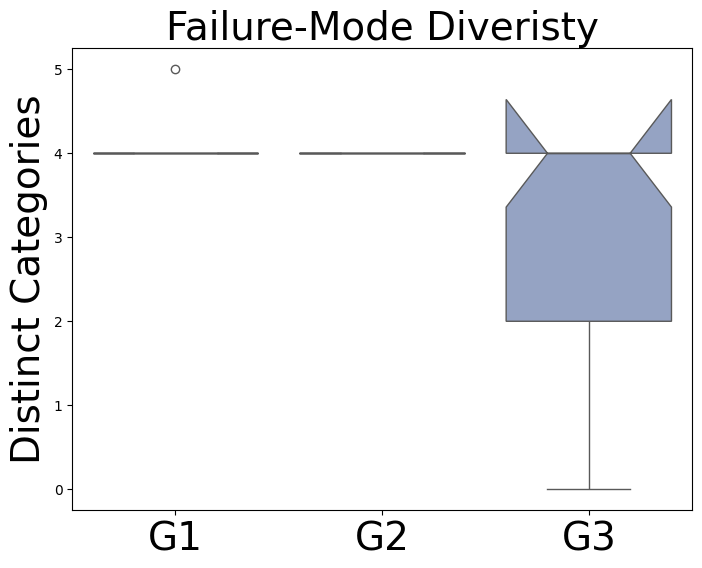

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='num_distinct_failures',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Failure-Mode Diveristy', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_failure_mode_diversity_specifcation.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_failure_mode_diversity_specifcation.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [97]:
df.groupby('specification')[["CO",	"EC",	"AI",	"IV",	"TB", "num_distinct_failures"]].mean() ## average diversity

,CO,EC,AI,IV,TB,num_distinct_failures
specification,,,,,,
G1,8.416667,3.666667,5.250000,4.166667,0.041667,4.041667
G2,7.750000,3.625000,4.458333,3.833333,0.000000,4.000000
G3,5.500000,2.333333,2.125000,1.416667,0.000000,3.208333


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/987525029.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/987525029.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


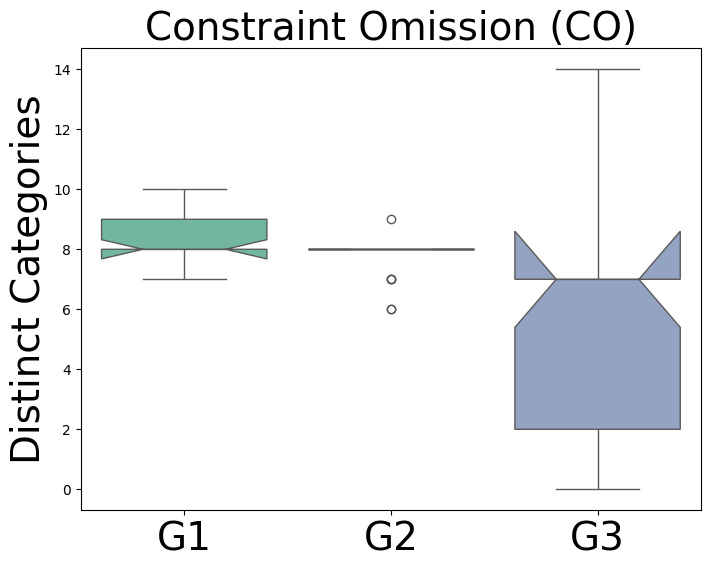

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='CO',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Constraint Omission (CO)', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_CO.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_CO.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/2051512346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/2051512346.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


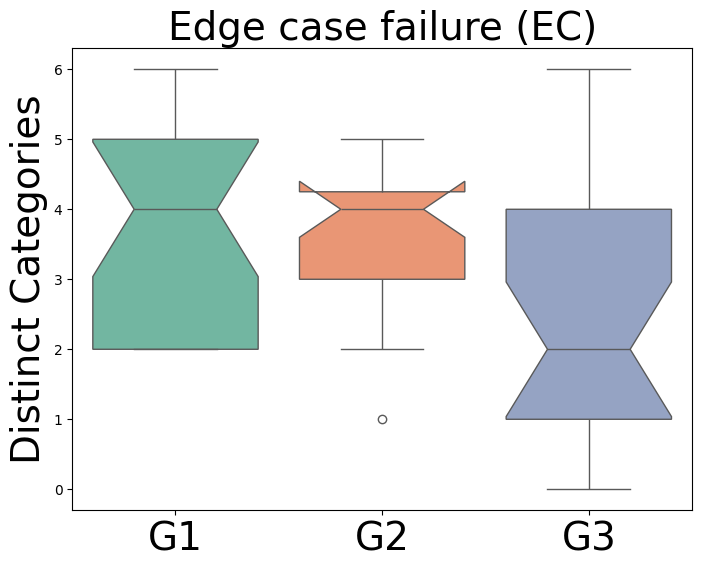

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='EC',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Edge case failure (EC)', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_EC.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_EC.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3478155623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/3478155623.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


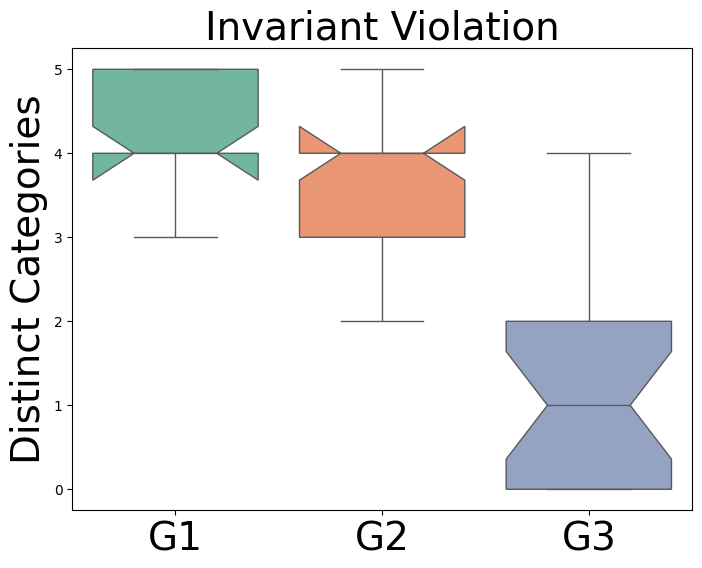

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='IV',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Invariant Violation', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_IV.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_IV.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/1644865249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/1644865249.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


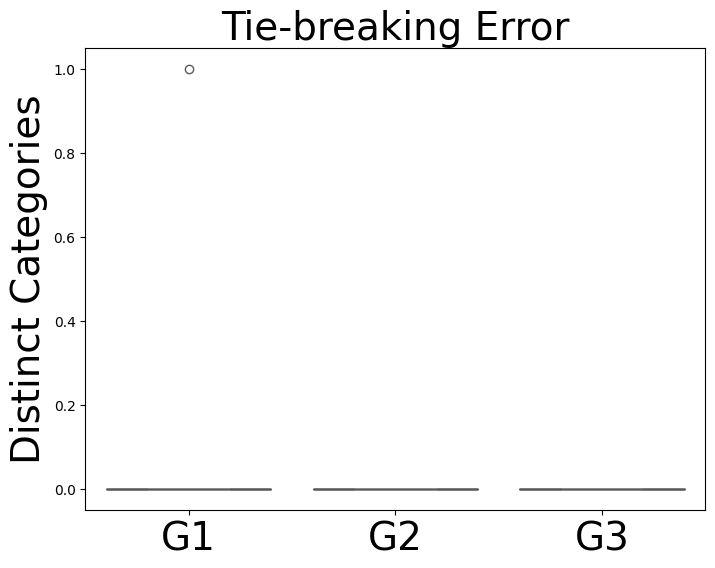

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='TB',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Tie-breaking Error', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_TB.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_TB.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/928545722.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_52079/928545722.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


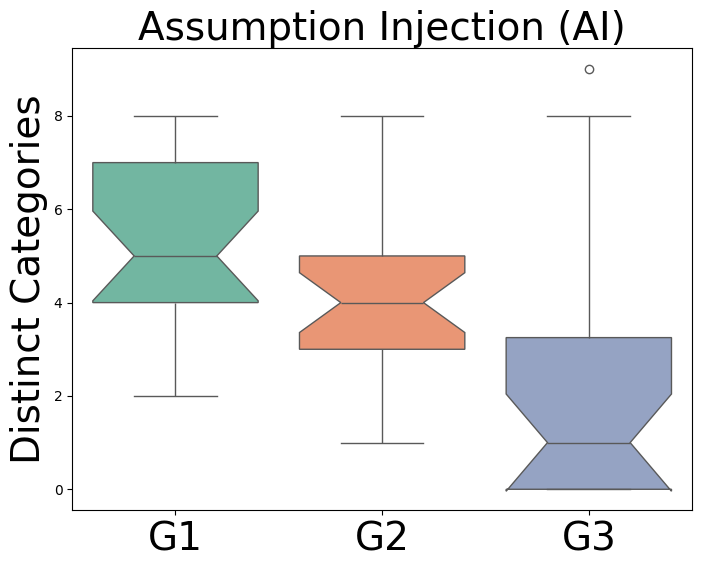

In [ ]:
# Set a colorful palette
palette = sns.color_palette("Set2")  # you can try "Set1", "pastel", "tab10", etc.

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(
    x='specification',
    y='AI',
    data=df,
    notch=True,
    palette=palette
)

plt.title('Assumption Injection (AI)', fontsize=28)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=28)
plt.ylabel('Distinct Categories', fontsize=28)
plt.savefig('img/RQ1_AI.png', dpi=300, bbox_inches='tight')
plt.savefig('img/RQ1_AI.pdf', dpi=300, bbox_inches='tight')
plt.show()

#### Run one-way ANOVA

In [ ]:
g1 = df[df['specification']=='G1']['num_distinct_failures']
g2 = df[df['specification']=='G2']['num_distinct_failures']
g3 = df[df['specification']=='G3']['num_distinct_failures']

F, p = f_oneway(g1, g2, g3)

print("F =", F)
print("p =", p)

F = 10.457040572792366
p = 0.00010795372165313811


In [ ]:
model = ols('num_distinct_failures ~ C(specification)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                     sum_sq    df          F    PR(>F)
C(specification)  10.583333   2.0  10.457041  0.000108
Residual          34.916667  69.0        NaN       NaN


In [ ]:
# Tukey HSD for failure count
tukey_failure = pairwise_tukeyhsd(endog=df['num_distinct_failures'], groups=df['specification'], alpha=0.05)
print(tukey_failure)


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    G1     G2  -0.0417 0.9776 -0.5336  0.4502  False
    G1     G3  -0.8333 0.0004 -1.3252 -0.3414   True
    G2     G3  -0.7917 0.0007 -1.2836 -0.2998   True
----------------------------------------------------


### frequency

In [ ]:
import pandas as pd
df = pd.read_csv("Datasets/Phase1/failure_modes_phase1.csv")
categories = ['CO', 'EC', 'AI', 'IV', 'TB']

# Expand failed_categories into separate columns with counts
for cat in categories:
    df[cat] = df['failed_categories'].apply(lambda x: x.count(cat))

for cat in categories:
    df[cat + "_p"] = df['passed_categories'].apply(lambda x: x.count(cat))

for cat in categories:
    df[f'{cat}_total'] = df[f'{cat}'] + df[f'{cat}_p']

cols_to_keep = ["specification", 'CO', 'EC', 'AI', 'IV', 'TB', 'CO_total', 'EC_total', 'AI_total', 'IV_total', 'TB_total']

df_filtered = df[cols_to_keep]
df_filtered = df_filtered.groupby('specification').sum()

for cat in categories:
    df_filtered[cat + "_norm"] = df_filtered[cat] / df_filtered[cat + "_total"] *100

In [8]:
df_filtered = df_filtered[["CO_norm",	"EC_norm",	"AI_norm",	"IV_norm",	"TB_norm"]]
df_filtered

,CO_norm,EC_norm,AI_norm,IV_norm,TB_norm
specification,,,,,
G1,73.188406,48.888889,58.333333,92.592593,8.333333
G2,67.391304,48.333333,49.537037,85.185185,0.000000
G3,47.826087,31.111111,23.611111,31.481481,0.000000


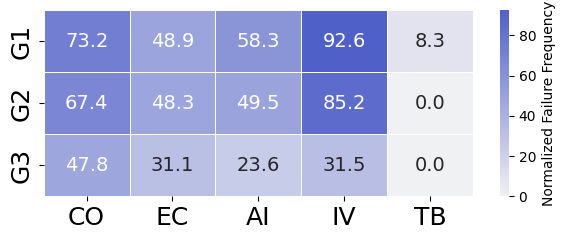

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cmap = sns.light_palette("#4f60c9", as_cmap=True)
plt.figure(figsize=(6, 2.5))
ax = sns.heatmap(
    df_filtered,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Normalized Failure Frequency"},
    annot_kws={"size": 14} 
)

# Set custom x-axis labels
new_labels = ["CO", "EC", "AI", "IV", "TB"]  # replace with whatever you want
ax.set_xticklabels(new_labels, fontsize=18)

# Adjust y-axis tick size
ax.tick_params(axis='y', labelsize=18)
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("Failure_mode_freq.pdf")
plt.show()

#### CO

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Example: predict whether CO failure occurred in a row
df['CO_failure'] = df['failed_categories'].apply(lambda x: 1 if 'CO' in x else 0)
# Use some predictors, for example 'Task' and 'specification'
# Convert categorical variables to dummy variables
X = pd.get_dummies(df[['Task', 'specification']], drop_first=True)

# Add constant for intercept
X = sm.add_constant(X)
# Convert X to numeric explicitly
X = X.astype(float)
# Outcome variable
y = df['CO_failure']
y = y.astype(int)


In [120]:
# Fit logistic regression
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Odds ratios and p-values
import numpy as np
summary = pd.DataFrame({
    'coef': result.params,
    'odds_ratio': np.exp(result.params),
    'p_value': result.pvalues
})
print(summary)

         Current function value: 0.047806
         Iterations: 35
                       coef    odds_ratio   p_value
const             23.842085  2.261964e+10  0.999562
Task_B            16.127759  1.009710e+07  0.995770
specification_G2   4.000420  5.462106e+01  0.999990
specification_G3 -21.444189  4.863030e-10  0.999606


/Users/elmiraonagh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# over all

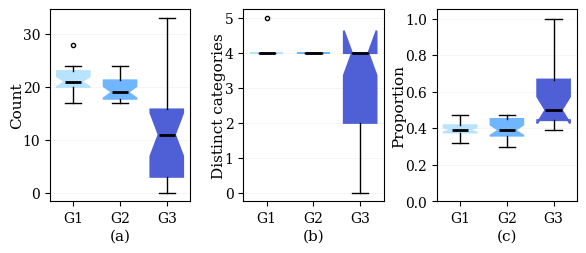

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
# from google.colab import files

# -----------------------------
# 1. Load CSV files
# -----------------------------
hidden_tests = pd.read_csv("Datasets/Phase1/hidden_tests_phase1.csv")
dataset = pd.read_csv("Datasets/Phase1/dataset_phase1.csv")
failure_modes = pd.read_csv("Datasets/Phase1/failure_modes_phase1.csv")

# -----------------------------
# 2. Detect columns
# -----------------------------
def find_col(df, candidates):
    low = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    for c in df.columns:
        cl = c.lower()
        if any(k.lower() in cl for k in candidates):
            return c
    return None

id_col_h = find_col(hidden_tests, ["id","participant_id"])
spec_col_h = find_col(hidden_tests, ["specification","group","condition"])
fail_col = find_col(hidden_tests,
    ["num_hidden_test_failed_phase1","hidden_failures","failed_tests","num_failed"])

id_col_f = find_col(failure_modes, ["id","participant_id"])
spec_col_f = find_col(failure_modes, ["specification","group","condition"])
cat_col = find_col(failure_modes, ["failed_categories","categories","failure_modes"])

# -----------------------------
# 3. Build measures
# -----------------------------
m1 = hidden_tests[[id_col_h,spec_col_h,fail_col]].copy()
m1.columns = ["id","specification","hidden_failures"]

fm = failure_modes[[id_col_f,spec_col_f,cat_col]].copy()
fm.columns = ["id","specification","failed_categories"]

def parse_list(x):
    if pd.isna(x): return []
    if isinstance(x,list): return x
    try:
        return ast.literal_eval(x)
    except:
        return [s.strip() for s in str(x).split(",") if s.strip()]

fm["failed_categories"] = fm["failed_categories"].apply(parse_list)

fm["failure_mode_diversity"] = fm["failed_categories"].apply(
    lambda xs: len(set(xs)) if len(xs)>0 else 0)

fm["co_proportion"] = fm["failed_categories"].apply(
    lambda xs: sum(1 for x in xs if str(x).upper()=="CO")/len(xs) if len(xs)>0 else np.nan)

rq1 = m1.merge(
    fm[["id","specification","failure_mode_diversity","co_proportion"]],
    on=["id","specification"],
    how="inner"
)

# -----------------------------
# 4. Group ordering
# -----------------------------
rq1["specification"] = rq1["specification"].astype(str).str.strip()

group_order = ["G1","G2","G3"]
existing = [g for g in group_order if g in rq1["specification"].unique()]
if len(existing)!=3:
    existing = sorted(rq1["specification"].unique())

def grouped_values(df,col):
    return [df.loc[df["specification"]==g,col].dropna().values for g in existing]

hidden_failures_data = grouped_values(rq1,"hidden_failures")
diversity_data = grouped_values(rq1,"failure_mode_diversity")
co_prop_data = grouped_values(rq1,"co_proportion")

# -----------------------------
# 5. Style
# -----------------------------
plt.rcParams.update({
    "font.family":"serif",
    "font.size":10,
    "axes.labelsize":11,
    "axes.facecolor":"white",
    "figure.facecolor":"white",
    "savefig.facecolor":"white"
})

colors = ["#b7e3ff","#6fb6ff","#4f5fd5"]

fig,axes = plt.subplots(1,3,figsize=(6.8,3.0))
fig.subplots_adjust(wspace=0.38,bottom=0.24)

# -----------------------------
# 6. Boxplot function
# -----------------------------
def styled_boxplot(ax,data,ylabel,ylim=None):

    positions = [1.00,1.10,1.20]

    bp = ax.boxplot(
        data,
        positions=positions,
        notch=True,
        patch_artist=True,
        widths=0.07,
        whis=1.5,
        medianprops=dict(color="black",linewidth=2),
        whiskerprops=dict(color="black",linewidth=1),
        capprops=dict(color="black",linewidth=1),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3
        )
    )

    # make border same color as fill
    for patch,color in zip(bp["boxes"],colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.4)

    ax.set_ylabel(ylabel, labelpad=-1)
    ax.set_xticks(positions)
    ax.set_xticklabels(existing)
    ax.set_xlim(0.95,1.25)

    if ylim:
        ax.set_ylim(*ylim)

    ax.grid(axis="y",linestyle="-",linewidth=0.6,alpha=0.15)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# -----------------------------
# 7. Draw plots
# -----------------------------
styled_boxplot(axes[0],hidden_failures_data,"Count")
styled_boxplot(axes[1],diversity_data,"Distinct categories")
styled_boxplot(axes[2],co_prop_data,"Proportion",(0,1.05))

labels = ["(a)","(b)","(c)"]

for i,ax in enumerate(axes):
    ax.text(0.5,-0.18,labels[i],
            transform=ax.transAxes,
            ha="center",va="center",
            fontsize=11)

# -----------------------------
# 8. Save
# -----------------------------
output_pdf="img/RQ1_boxplot_final.pdf"

fig.savefig(output_pdf,bbox_inches="tight",facecolor="white")

plt.show()

